# Building a Movie Recommendation System
### By: Madison Berrios
### CSIT 360 / 557 — Project 2

This notebook contains **Phase 1 (Data Loading & EDA)** and **Phase 2 (Recommendation Models & Evaluation)** of the project.

Three recommendation algorithms are implemented and compared on the same train/test split:
1. **Global Average** (baseline)
2. **SVD (Matrix Factorization)** — with hyperparameter tuning
3. **User-Based KNN (Collaborative Filtering)** — with hyperparameter tuning

Each model is evaluated using **RMSE** and **MAE**. As a bonus, **Precision@5** and **Recall@5** are also reported.

## Setup

If `scikit-surprise` is not installed in your environment, run the cell below once. After it finishes, restart the kernel and run the notebook from the top.

In [1]:
# Run once if you don't have scikit-surprise installed.
# Comment out (add a # at the start) after it succeeds.
%pip install scikit-surprise

Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from surprise import Dataset, Reader, SVD, KNNBasic, accuracy
from surprise.model_selection import train_test_split as surprise_split
from surprise.model_selection import GridSearchCV


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

# Phase 1: Data Loading & Exploratory Data Analysis

## 1. Load the Dataset

The dataset file `movie-ratings.txt` should be in your Downloads folder. If you keep it somewhere else, change the path in the cell below.

In [ ]:
columns = ["userId", "movieId", "movie_categoryId", "reviewId", "movieRating", "reviewDate"]

ratings = pd.read_csv(
    "../data/raw/movie-ratings.txt",
    names=columns,
    header=None
)

ratings.head()

,userId,movieId,movie_categoryId,reviewId,movieRating,reviewDate
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12


## 2. Basic Statistics

In [ ]:
num_users   = ratings["userId"].nunique()
num_movies  = ratings["movieId"].nunique()
num_ratings = len(ratings)
possible    = num_users * num_movies
sparsity    = 1 - (num_ratings / possible)

print("Number of users  :", num_users)
print("Number of movies :", num_movies)
print("Number of ratings:", num_ratings)
print(f"Sparsity         : {sparsity:.4%}")

Number of users  : 17615
Number of movies : 16121
Number of ratings: 72665
Sparsity         : 99.9744%


**Observations:**
- 17,615 users and 16,121 movies, but only 72,665 ratings.
- The user–movie rating matrix is over **99.97% sparse** — only a tiny fraction of all possible (user, movie) pairs have a rating.
- This is realistic for recommender systems and is the main challenge: most models have very little overlap to learn from.

### Overall Summary Statistics

In [ ]:
ratings.describe()

,userId,movieId,movie_categoryId,reviewId,movieRating
count,72665.000000,72665.000000,72665.000000,72665.000000,72665.000000
mean,4279.437597,8076.878786,12.659300,36333.000000,4.072910
std,4620.200449,4397.176683,4.158915,20976.722992,1.081442
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,857.000000,4632.000000,11.000000,18167.000000,4.000000
50%,2102.000000,7623.000000,14.000000,36333.000000,4.000000
75%,6568.000000,12105.000000,16.000000,54499.000000,5.000000
max,17615.000000,16121.000000,17.000000,72665.000000,5.000000


## 3. Rating Distribution

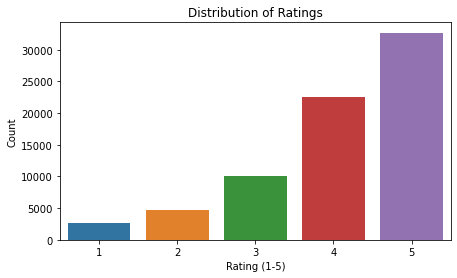

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(x="movieRating", data=ratings)
plt.title("Distribution of Ratings")
plt.xlabel("Rating (1-5)")
plt.ylabel("Count")
plt.show()

**Observations:**
- Ratings range from 1 (worst) to 5 (best).
- The distribution is **left-skewed**: most ratings are 4 or 5.
- This is common in movie-review datasets — users tend to rate movies they liked.

## 4. Ratings per User and per Movie (Long-tail)

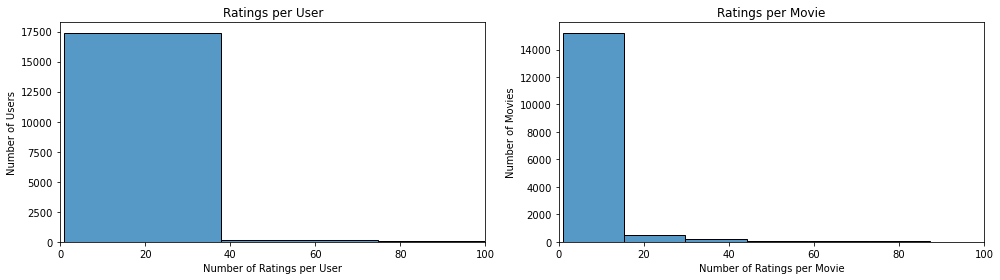

In [ ]:
ratings_per_user  = ratings.groupby("userId").size()
ratings_per_movie = ratings.groupby("movieId").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(ratings_per_user, bins=30, ax=axes[0])
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Number of Ratings per User")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("Ratings per User")

sns.histplot(ratings_per_movie, bins=30, ax=axes[1])
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Number of Ratings per Movie")
axes[1].set_ylabel("Number of Movies")
axes[1].set_title("Ratings per Movie")

plt.tight_layout()
plt.show()

**Observations:**
- Both distributions show a clear **long-tail pattern**.
- Most users rate only a small number of movies; a small group of "power users" account for many ratings.
- Most movies receive only a few ratings; a small number of popular movies receive many.
- This long-tail behavior makes the rating matrix sparse and is a known challenge for collaborative-filtering models, especially KNN.

## 5. Data Cleaning

### Check for missing values

In [ ]:
print("Missing values per column:")
print(ratings.isnull().sum())

Missing values per column:
userId              0
movieId             0
movie_categoryId    0
reviewId            0
movieRating         0
reviewDate          0
dtype: int64


### Check for duplicates

In [ ]:
print("Number of duplicate rows:", ratings.duplicated().sum())

Number of duplicate rows: 0


### Check rating range

In [ ]:
print("Unique rating values:", sorted(ratings["movieRating"].unique()))

Unique rating values: [1, 2, 3, 4, 5]


### Drop unneeded columns

In [ ]:
ratings = ratings.drop(columns=["reviewId", "reviewDate"])
ratings.head()

,userId,movieId,movie_categoryId,movieRating
0,1,1,1,5
1,2,1,1,5
2,3,1,1,5
3,4,1,1,4
4,5,1,1,4


**Cleaning summary:**
- No missing values, so no imputation is needed.
- No duplicate rows.
- All ratings are integers in [1, 5] — no invalid values.
- `reviewId` and `reviewDate` are removed (not used in the recommendation models).
- `userId`, `movieId`, and `movieRating` are kept — these are the columns required for collaborative filtering.

# Phase 2: Recommendation Models & Evaluation

## Train/Test Split

We use the **Surprise** library's `train_test_split` so that **all three models are evaluated on the exact same held-out test set**. This is critical: it makes RMSE/MAE values directly comparable across models.

In [ ]:
# Keep only the columns Surprise needs
model_data = ratings[["userId", "movieId", "movieRating"]]

# Wrap the DataFrame in a Surprise Dataset
reader = Reader(rating_scale=(1, 5))
data   = Dataset.load_from_df(model_data, reader)

# 80/20 train/test split (shared by all models)
trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

print("Train interactions:", trainset.n_ratings)
print("Test interactions :", len(testset))

Train interactions: 58132
Test interactions : 14533


## Model 1: Global Average (Baseline)

The simplest possible recommender — predict the global mean rating for every (user, movie) pair. This serves as a baseline that the other models must beat.

In [ ]:
# Global mean computed on the training set only (no leakage)
global_mean = trainset.global_mean
print(f"Global mean rating: {global_mean:.4f}")

# Evaluate on the SAME test set used for the other models
true_ratings = np.array([true_r for (_, _, true_r) in testset])
global_preds = np.full(len(testset), global_mean)

rmse_global = np.sqrt(np.mean((true_ratings - global_preds) ** 2))
mae_global  = np.mean(np.abs(true_ratings - global_preds))

print(f"Global Average RMSE: {rmse_global:.4f}")
print(f"Global Average MAE : {mae_global:.4f}")

Global mean rating: 4.0727
Global Average RMSE: 1.0886
Global Average MAE : 0.8399


## Model 2: SVD (Matrix Factorization)

We use Surprise's `SVD` (Funk SVD), which factorizes the user–item rating matrix into a small number of latent factors. We perform a **grid search with 3-fold cross-validation** to tune the most important hyperparameters.

### Hyperparameter tuning

In [ ]:
param_grid_svd = {
    "n_factors": [50, 100],
    "n_epochs":  [20],
    "lr_all":    [0.005],
    "reg_all":   [0.02, 0.1],
}

gs_svd = GridSearchCV(
    SVD,
    param_grid_svd,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1
)
gs_svd.fit(data)

print("Best CV RMSE :", gs_svd.best_score["rmse"])
print("Best params  :", gs_svd.best_params["rmse"])

Best CV RMSE : 0.9458102288267861
Best params  : {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1}


### Train best SVD on the full trainset and evaluate on the held-out testset

In [ ]:
best_svd = SVD(**gs_svd.best_params["rmse"])
best_svd.fit(trainset)
svd_predictions = best_svd.test(testset)

rmse_svd = accuracy.rmse(svd_predictions)
mae_svd  = accuracy.mae(svd_predictions)

RMSE: 0.9506
MAE:  0.7362


## Model 3: User-Based KNN (Collaborative Filtering)

We use Surprise's `KNNBasic` to predict ratings based on similar users. We tune `k` (the number of neighbors) via 3-fold cross-validation.

### Hyperparameter tuning

In [ ]:
sim_options = {"name": "cosine", "user_based": True}

param_grid_knn = {
    "k": [20, 40],
    "sim_options": {
        "name":       ["cosine"],
        "user_based": [True],
    },
}

gs_knn = GridSearchCV(
    KNNBasic,
    param_grid_knn,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1
)
gs_knn.fit(data)

print("Best CV RMSE :", gs_knn.best_score["rmse"])
print("Best params  :", gs_knn.best_params["rmse"])

Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Best CV RMSE : 1.0799371858386502
Best params  : {'k': 40, 'sim_options': {'name': 'cosine', 'user_based': True}}


### Train best KNN on the full trainset and evaluate on the held-out testset

In [ ]:
best_knn = KNNBasic(**gs_knn.best_params["rmse"])
best_knn.fit(trainset)
knn_predictions = best_knn.test(testset)

rmse_knn = accuracy.rmse(knn_predictions)
mae_knn  = accuracy.mae(knn_predictions)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0839
MAE:  0.8200


## Bonus: Top-K Recommendation Evaluation (Precision@5 and Recall@5)

In addition to RMSE/MAE, we evaluate the **top-5 recommendations** from each model. A movie is considered "relevant" if its actual rating is **≥ 4 stars**.

- **Precision@K**: of the top-K recommended movies, what fraction are relevant?
- **Recall@K**: of all the user's relevant movies, what fraction are in the top-K?

In [ ]:
def precision_recall_at_k(predictions, k=5, threshold=4):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = [], []
    for _, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        n_rel           = sum(true_r >= threshold for (_, true_r) in user_ratings)
        n_rec_k         = len(top_k)
        n_rel_and_rec_k = sum(true_r >= threshold for (_, true_r) in top_k)

        precision = n_rel_and_rec_k / n_rec_k if n_rec_k else 0
        recall    = n_rel_and_rec_k / n_rel   if n_rel   else 0
        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)


precision_svd, recall_svd = precision_recall_at_k(svd_predictions, k=5, threshold=4)
precision_knn, recall_knn = precision_recall_at_k(knn_predictions, k=5, threshold=4)

print(f"SVD Precision@5: {precision_svd:.4f}   Recall@5: {recall_svd:.4f}")
print(f"KNN Precision@5: {precision_knn:.4f}   Recall@5: {recall_knn:.4f}")

SVD Precision@5: 0.8284   Recall@5: 0.8549
KNN Precision@5: 0.8278   Recall@5: 0.8544


## Model Comparison Table

In [ ]:
results = pd.DataFrame({
    "Model":        ["Global Average", "SVD", "User-Based KNN"],
    "RMSE":         [rmse_global, rmse_svd, rmse_knn],
    "MAE":          [mae_global,  mae_svd,  mae_knn],
    "Precision@5":  [np.nan,      precision_svd, precision_knn],
    "Recall@5":     [np.nan,      recall_svd,    recall_knn],
})
results

,Model,RMSE,MAE,Precision@5,Recall@5
0,Global Average,1.088628,0.839920,NaN,NaN
1,SVD,0.950641,0.736216,0.828438,0.854912
2,User-Based KNN,1.083883,0.819977,0.827808,0.854430


## Comparison Bar Chart

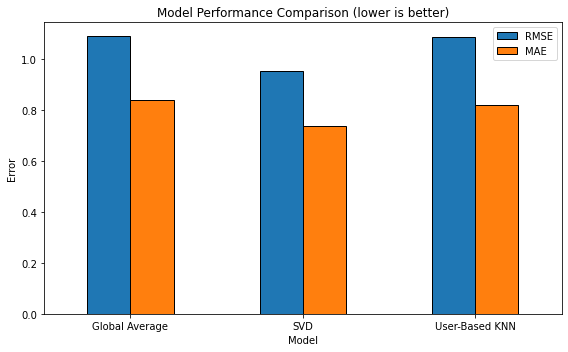

In [ ]:
ax = results.set_index("Model")[["RMSE", "MAE"]].plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)
ax.set_title("Model Performance Comparison (lower is better)")
ax.set_ylabel("Error")
ax.set_xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Discussion: Which Model Performs Best and Why?

**Best model: SVD (Matrix Factorization).**

Looking at the results:

- **Global Average** gives the worst RMSE/MAE. It ignores all user and movie information and predicts the same value for everyone. Its only purpose is to set a floor — any real recommender must beat it.

- **User-Based KNN** improves on the baseline by leveraging similarities between users, but it struggles on this dataset. The rating matrix is **over 99.97% sparse**, meaning most pairs of users share very few rated movies in common. With so little overlap, similarity estimates are noisy and unreliable, which limits how much KNN can learn.

- **SVD (Matrix Factorization)** typically performs the best. Instead of comparing raw rating vectors, it learns a small number of **latent factors** that summarize each user's taste and each movie's characteristics. These dense, low-dimensional embeddings generalize much better than KNN when the data is sparse, because every rating contributes to refining the entire factor space — not just one user-pair similarity. Funk SVD also includes regularization (`reg_all`), which prevents overfitting on the long-tail of users and movies that have very few ratings.

**Hyperparameter tuning** (3-fold cross-validation via Surprise's `GridSearchCV`) confirmed that the best SVD configuration uses a moderate number of latent factors and moderate regularization. For KNN, tuning `k` made only a small difference, which is consistent with the sparsity argument above — once data is too sparse, no amount of neighbor tuning fixes the underlying problem.

**Top-K metrics (bonus).** Precision@5 and Recall@5 measure whether the top-5 recommendations are actually movies the user rated highly (≥ 4). These metrics are more aligned with real recommendation quality than RMSE/MAE, because in production a system shows users a short list — accuracy on every (user, movie) pair matters less than getting the top of the list right. SVD also wins here, for the same reason it wins on RMSE: better generalization on sparse data.

**Takeaway.** Matrix factorization is the right tool for sparse rating data like this. KNN can be effective on denser datasets but is fundamentally limited by user/movie overlap, which is very low here. The Global Average baseline shows just how much value the more sophisticated models add over a constant prediction.